# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [1]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

In [2]:

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')

## 모듈 import

In [3]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [4]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개


## 시뮬레이션 실행

In [5]:
from algorithms.rule_based import RuleBasedDispatch

# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
algorithm = RuleBasedDispatch(env=env)
scheduler = Scheduler(env=env, data=data, event_logger=event_logger, algorithm=algorithm)

## 시뮬레이션 실행

In [6]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [7]:
scheduler.get_simulation_info()

Job ID: J1	QTime Violation: 0.0	완료 시간: 55
Job ID: J2	QTime Violation: 12.0	완료 시간: 52
Job ID: J3	QTime Violation: 15.0	완료 시간: 80
Job ID: J4	QTime Violation: 20.0	완료 시간: 153
Job ID: J5	QTime Violation: 12.0	완료 시간: 90
Job ID: J6	QTime Violation: 1.0	완료 시간: 104
Job ID: J7	QTime Violation: 10.0	완료 시간: 91
Job ID: J8	QTime Violation: 17.0	완료 시간: 108
Job ID: J9	QTime Violation: 26.0	완료 시간: 148
Job ID: J10	QTime Violation: 1.643	완료 시간: 109
시뮬레이션 시간: 153
총 작업 수: 10
완료된 작업 수: 10
기한 안에 완료된 작업 수: 0
총 QTime 위반 시간: 114.643


,waiting,setup,working,job_type
id,,,,
J1,11.000,0.0,44.000,P1
J3,29.000,0.0,51.000,P1
J5,28.000,0.0,62.000,P1
J7,23.000,12.0,56.000,P1
J9,87.000,0.0,61.000,P1
J10,70.000,0.0,39.000,P2
J2,21.000,0.0,31.000,P2
J4,103.000,0.0,50.000,P2
J6,51.357,7.0,45.643,P2


findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
C:\Users\ryulh\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ryulh\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
findfont: Font family 'Noto San

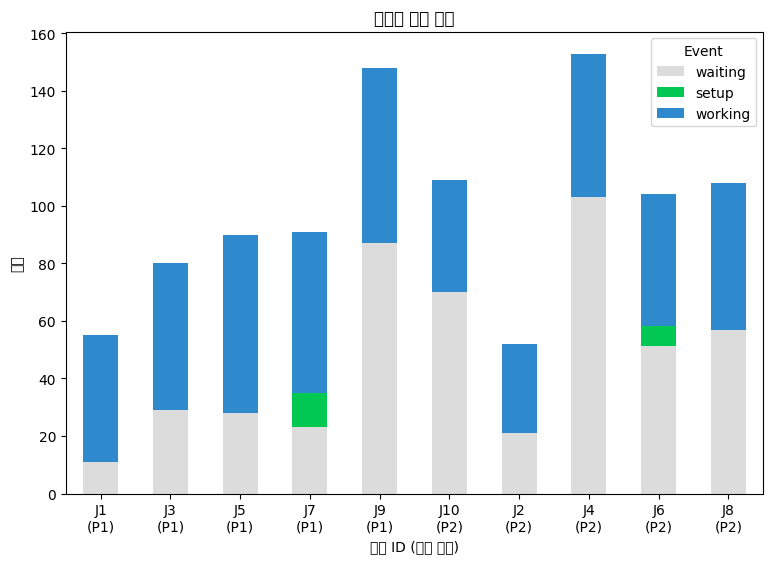

In [8]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_stacked = job_stacked.join(job_type_map).sort_values('job_type')
display(job_stacked)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
job_stacked.plot(kind='bar', stacked=True, figsize=(9, 6), color={
    "waiting": '#DCDCDC',
    "setup": '#00C853',
    "working": '#2E89CD'
})
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.xticks(rotation=0)
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.450980,G1
M2,0.346405,G1
M3,0.411765,G1
M4,0.529412,G2
M5,0.455183,G2
M6,0.379085,G3
M7,0.156863,G3
M8,0.379085,G3


C:\Users\ryulh\AppData\Local\Temp\ipykernel_23528\3043275448.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
C:\Users\ryulh\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning:

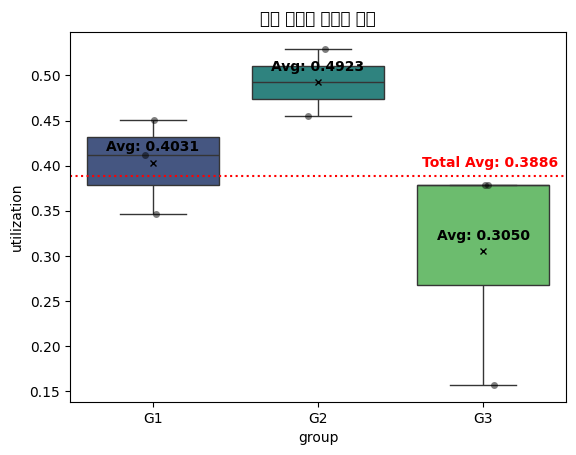

In [9]:
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()